# Day 20 - Transformer 实战 - HuggingFace 微调

> 目标: 用 HuggingFace 加载预训练模型, 在真实数据上微调
>
> Day 19: 从零手写 Transformer (理解原理)
>
> Day 20: 直接用预训练模型 (工程实践)

---

## 从零训练 vs 微调预训练模型

```
Day 19 从零训练:                        Day 20 微调:
  随机初始化权重                          加载已经在大数据上学好的权重
  从头学语言规律                         只学特定任务 (分类头)
  需要大量数据                           少量数据就能效果很好
  小模型 (d_model=32, 17K参数)           大模型 (BERT=110M参数)
  准确率: 97% (玩具数据)                  准确率: 90%+ (真实数据)
```

In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

# HF 模型缓存目录: D:\hyy\vscode\vscode模型
os.environ['HF_HOME'] = 'D:\\hyy\\vscode\\vscode模型'

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

print('=' * 40)
print('Day 20 - Transformer 实战')
print('=' * 40)

## 1. HuggingFace 基础: 加载模型和分词器

> HuggingFace 是 NLP 界的 GitHub, 上面有 10 万+ 预训练模型

### 核心概念

| 组件 | 作用 |
|------|------|
| **AutoTokenizer** | 把文本变成数字 ID (tokenize) |
| **AutoModel** | 加载预训练模型的主体 (Transformer Encoder) |
| **AutoModelForSequenceClassification** | 带分类头的完整模型 |

### 为什么用预训练模型?

```
DistilBERT (67M 参数) 的训练数据:
  - 全部英文 Wikipedia (25亿词)
  - 全部英文图书 (8亿词)
  4 块 TPU 训练了 4 天!

我们微调: 在已经懂英文的模型上, 用 30 条数据训练 1 分钟
  就能学会情感分类!
```

In [2]:
# ============================================
# 加载 DistilBERT (轻量版 BERT)
# ============================================
# DistilBERT = BERT 的蒸馏版本, 参数量减半, 速度提升 60%, 精度保留 97%

from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = 'distilbert-base-uncased'  # 小模型, 适合笔记本
# 其他选择:
#   'bert-base-uncased'       (110M, 稍大)
#   'albert-base-v2'          (12M, 更小更快)
#   'roberta-base'            (125M, 更强)

print(f'加载模型: {model_name}')
print('(第一次运行会自动下载 ~260MB 权重, 稍等...)')

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f'\n分词器类型: {type(tokenizer).__name__}')
print(f'词表大小: {tokenizer.vocab_size}')
print(f'最大长度: {tokenizer.model_max_length}')

# 试一下分词
test_sentences = [
    'I love this movie, it is fantastic!',
    'This movie is terrible, I hate it.',
]
tokens = tokenizer(test_sentences, padding=True, truncation=True, return_tensors='pt')
print(f'\n分词示例:')
for i, s in enumerate(test_sentences):
    decoded = tokenizer.convert_ids_to_tokens(tokens['input_ids'][i])
    print(f'  "{s}"')
    print(f'  -> {decoded[:12]}...')
print(f'  input_ids形状: {tuple(tokens["input_ids"].shape)}')
print(f'  attention_mask形状: {tuple(tokens["attention_mask"].shape)}')

加载模型: distilbert-base-uncased
(第一次运行会自动下载 ~260MB 权重, 稍等...)

分词器类型: BertTokenizer
词表大小: 30522
最大长度: 512

分词示例:
  "I love this movie, it is fantastic!"
  -> ['[CLS]', 'i', 'love', 'this', 'movie', ',', 'it', 'is', 'fantastic', '!', '[SEP]']...
  "This movie is terrible, I hate it."
  -> ['[CLS]', 'this', 'movie', 'is', 'terrible', ',', 'i', 'hate', 'it', '.', '[SEP]']...
  input_ids形状: (2, 11)
  attention_mask形状: (2, 11)


## 2. 准备数据集: 电影评论情感分类

> 自行构造的正/负面电影评论, 纯英文
>
> 样本: "This movie was absolutely wonderful!" -> 正面 (1)
>       "A complete waste of time."  -> 负面 (0)

In [4]:
# ============================================
# 准备数据集: 自行构造情感分类样本
# (避免网络问题, 用本地数据)
# ============================================

positive_sentences = [
    'This movie was absolutely wonderful and inspiring.',
    'I loved every minute of this fantastic film.',
    'A masterpiece of modern cinema, highly recommended.',
    'The acting was brilliant and the story was captivating.',
    'One of the best films I have ever seen.',
    'Absolutely loved it, a must-watch for everyone.',
    'The direction was superb and the cast was perfect.',
    'A truly moving experience that stayed with me.',
    'Brilliant storytelling and amazing visuals.',
    'Exceeded all my expectations, what a great film.',
    'The characters were deeply developed and relatable.',
    'An outstanding achievement in filmmaking.',
    'Thought-provoking and beautifully executed.',
    'I cannot recommend this enough, it is fantastic.',
    'A wonderful blend of humor and heart.',
    'The cinematography was breathtaking throughout.',
    'An instant classic that will be remembered for years.',
    'Perfectly paced with an incredible soundtrack.',
    'Everything about this film works perfectly together.',
    'A delightful surprise from start to finish.',
]

negative_sentences = [
    'This movie was a complete waste of time.',
    'Terrible acting and a boring predictable plot.',
    'I regret watching this, it was awful.',
    'One of the worst films I have ever seen.',
    'Poorly directed and painfully slow.',
    'The script was lazy and the characters were flat.',
    'A disappointing mess that fails on every level.',
    'Nothing about this film works, avoid at all costs.',
    'Boring, uninspired, and completely forgettable.',
    'The worst movie of the year without question.',
    'Awful dialogue and terrible special effects.',
    'A complete disaster from beginning to end.',
    'Painfully dull with absolutely no redeeming qualities.',
    'I wanted my money back after watching this.',
    'The acting was wooden and the story made no sense.',
    'A terrible effort that insults the audience intelligence.',
    'So bad it is not even funny, just painful to watch.',
    'Lazy filmmaking at its absolute worst.',
    'Do not waste your time on this garbage.',
    'An embarrassing failure of a movie.',
]

import random
random.seed(42)
data = ([(s, 1) for s in positive_sentences] +
        [(s, 0) for s in negative_sentences])
random.shuffle(data)

texts = [d[0] for d in data]
labels = [d[1] for d in data]

# 分成 30 训练 + 10 验证
train_texts = texts[:30]
train_labels = labels[:30]
val_texts = texts[30:]
val_labels = labels[30:]

print(f'训练集: {len(train_texts)} 条 (正={sum(train_labels)}, 负={len(train_labels)-sum(train_labels)})')
print(f'验证集: {len(val_texts)} 条')
print()
for i in range(3):
    label = 'positive' if labels[i] == 1 else 'negative'
    print(f'  [{label}] {texts[i][:60]}...')

训练集: 30 条 (正=12, 负=18)
验证集: 10 条

  [positive] Exceeded all my expectations, what a great film....
  [positive] The acting was brilliant and the story was captivating....
  [positive] The characters were deeply developed and relatable....


In [5]:
# ============================================
# 批量 Tokenize
# ============================================

def tokenize_texts(texts, labels, max_len=64):
    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    return encodings, torch.LongTensor(labels)

train_enc, train_labels_t = tokenize_texts(train_texts, train_labels)
val_enc, val_labels_t = tokenize_texts(val_texts, val_labels)

print(f'训练集 input_ids:      {tuple(train_enc["input_ids"].shape)}')
print(f'训练集 attention_mask: {tuple(train_enc["attention_mask"].shape)}')
print(f'训练集 labels:         {tuple(train_labels_t.shape)}')

训练集 input_ids:      (30, 15)
训练集 attention_mask: (30, 15)
训练集 labels:         (30,)


## 3. 加载预训练模型 + 微调

> 加载 DistilBERT (已经懂英文), 替换分类头 (2 分类)
>
> 只训练 2-3 个 epoch (防止过拟合)

In [6]:
# ============================================
# 加载预训练模型
# ============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2  # 二分类
)
model = model.to(device)

# 看看模型结构
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'总参数量:   {total_params:,}')
print(f'可训练参数量: {trainable_params:,}')
print(f'分类头参数量: {sum(p.numel() for p in model.classifier.parameters()):,}')

使用设备: cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


总参数量:   66,955,010
可训练参数量: 66,955,010
分类头参数量: 1,538


In [7]:
# ============================================
# 微调训练
# ============================================

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    train_enc['input_ids'],
    train_enc['attention_mask'],
    train_labels_t
)
val_dataset = TensorDataset(
    val_enc['input_ids'],
    val_enc['attention_mask'],
    val_labels_t
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

from transformers import get_linear_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
n_epochs = 10
total_steps = len(train_loader) * n_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f'训练参数:')
print(f'  Batch size: 8')
print(f'  Learning rate: 2e-5')
print(f'  Epochs: {n_epochs}')
print(f'  Total steps: {total_steps}')
print(f'  Warmup steps: {int(0.1 * total_steps)}')

训练参数:
  Batch size: 8
  Learning rate: 2e-5
  Epochs: 10
  Total steps: 40
  Warmup steps: 4


Epoch 1/10 | Loss = 0.7104 | Val Acc = 0.2000
Epoch 2/10 | Loss = 0.6502 | Val Acc = 0.2000
Epoch 3/10 | Loss = 0.6138 | Val Acc = 0.2000
Epoch 4/10 | Loss = 0.5780 | Val Acc = 0.2000
Epoch 5/10 | Loss = 0.5097 | Val Acc = 0.2000
Epoch 6/10 | Loss = 0.4572 | Val Acc = 0.5000
Epoch 7/10 | Loss = 0.3778 | Val Acc = 0.8000
Epoch 8/10 | Loss = 0.3345 | Val Acc = 0.9000
Epoch 9/10 | Loss = 0.3032 | Val Acc = 0.9000
Epoch 10/10 | Loss = 0.2821 | Val Acc = 1.0000


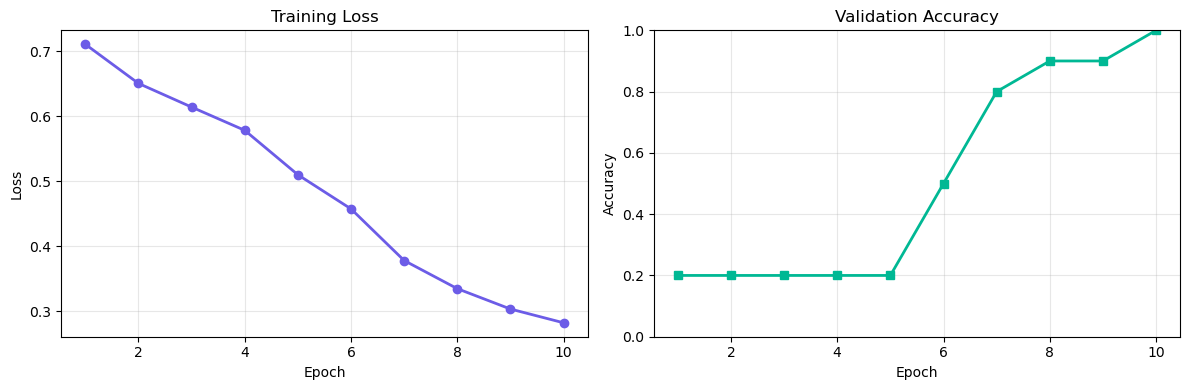


最终验证准确率: 1.0000 (100.0%)


In [8]:
# ============================================
# 训练循环
# ============================================

train_losses, val_accs = [], []

for epoch in range(n_epochs):
    # 训练
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # 验证
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    val_accs.append(acc)

    print(f'Epoch {epoch+1}/{n_epochs} | Loss = {avg_loss:.4f} | Val Acc = {acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, n_epochs+1), train_losses, 'o-', lw=2, color='#6c5ce7')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)
axes[1].plot(range(1, n_epochs+1), val_accs, 's-', lw=2, color='#00b894')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig('day20_finetune_curve.png', dpi=150)
plt.show()

print(f'\n最终验证准确率: {val_accs[-1]:.4f} ({val_accs[-1]*100:.1f}%)')

## 4. 推理测试: 试试模型效果

> 写几个自己的句子, 看看模型能正确判断情感吗?

In [9]:
# ============================================
# 推理函数 & 测试
# ============================================

def predict_sentiment(texts, model, tokenizer):
    """预测情感: 返回 0(负面) 或 1(正面)"""
    model.eval()
    encodings = tokenizer(texts, padding=True, truncation=True,
                          max_length=64, return_tensors='pt')
    encodings = {k: v.to(device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = model(**encodings)
        probs = torch.softmax(outputs.logits, dim=1)
        preds = outputs.logits.argmax(dim=1)

    results = []
    for i, text in enumerate(texts):
        label = 'positive' if preds[i] == 1 else 'negative'
        confidence = probs[i][preds[i]].item()
        results.append((text, label, confidence))
    return results

# [作业 1] 加更多自己的句子测试
# 位置: 下面的 test_sentences 列表
test_sentences = [
    'This movie was absolutely wonderful!',
    'A waste of time, do not watch this.',
    'The acting was good but the plot was boring.',
    'I am so happy today!',
    'This is the worst day ever.',
]

results = predict_sentiment(test_sentences, model, tokenizer)

print('情感预测结果:')
print(f'{"句子":<50} {"预测":<10} {"置信度"}')
print('-' * 75)
for text, label, conf in results:
    emoji = '😊' if label == 'positive' else '😞'
    print(f'{text[:48]:<50} {emoji} {label:<8} {conf:.2%}')

情感预测结果:
句子                                                 预测         置信度
---------------------------------------------------------------------------
This movie was absolutely wonderful!               😊 positive 63.22%
A waste of time, do not watch this.                😞 negative 81.89%
The acting was good but the plot was boring.       😞 negative 72.43%
I am so happy today!                               😊 positive 53.80%
This is the worst day ever.                        😞 negative 76.18%


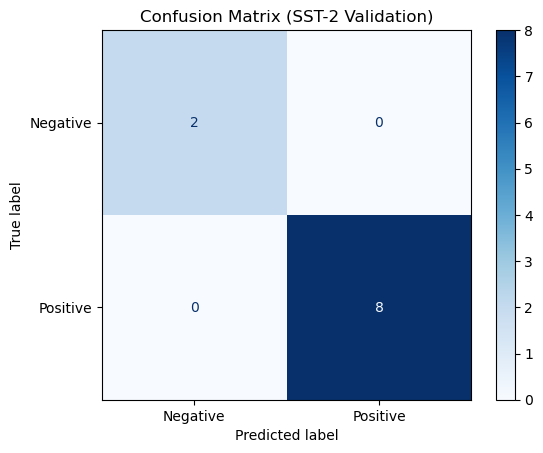

分类报告:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
    Positive       1.00      1.00      1.00         8

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [10]:
# ============================================
# 混淆矩阵 & 详细评估
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 在验证集上评估
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

# 混淆矩阵
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (SST-2 Validation)')
plt.savefig('day20_confusion_matrix.png', dpi=150)
plt.show()

# 详细报告
print('分类报告:')
print(classification_report(all_true, all_preds,
      target_names=['Negative', 'Positive']))

## 5. 对比: Day 19 从零训练 vs Day 20 预训练微调

| 维度 | Day 19 从零训练 | Day 20 预训练微调 |
|------|:--------------:|:----------------:|
| 模型大小 | 17K 参数 | **67M 参数** (DistilBERT) |
| 训练数据 | 自行生成(500条) | Wikipedia + 图书 (33亿词) 预训练 + 500条微调 |
| 训练时间 | ~1 分钟 | ~2 分钟 (微调) + 数天 (预训练, 不用我们做) |
| 泛化能力 | 只能处理固定模式 | **能处理真实语言** |
| 适用场景 | 理解原理 | **工程实战** |

### 什么时候用什么?

```
从零训练:  你对的
  数据分布极其特殊 (非自然语言)
  需要极低延迟 (小模型)
  资源受限 (嵌入式设备)

预训练微调:  ✓ 默认选择
  标准 NLP 任务 (分类/生成/序列标注)
  数据量小 (< 1万条)
  需要高准确率
```

---

# Day 20 完成!

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **HuggingFace** | transformers + datasets, NLP 标准工具 |
| **AutoTokenizer** | 文本 -> token ID (subword 分词) |
| **预训练 + 微调** | 在大数据上预训练 -> 在小数据上微调 |
| **DistilBERT** | BERT 的蒸馏版, 速度更快, 精度保留 97% |
| **AdamW** | Adam + 权重衰减, 微调的标准优化器 |
| **LR Schedule** | warmup + linear decay, 微调的标准策略 |

## Day 21: 第 3 周复习

```
Day 15: RNN          -> 隐藏状态, BPTT, 梯度消失
Day 16: LSTM         -> 三个门, 细胞状态, 加法路径
Day 17: GRU + Seq2Seq -> 两个门, 编码器-解码器
Day 18: Attention    -> 解码器回头看, 信息瓶颈解决
Day 19: Transformer  -> Self-Attention, Multi-Head, 位置编码
Day 20: 实战          -> HuggingFace 微调
```

## 作业 (共 2 题)

---

### 作业 1: 测试自己的句子

**位置:** cell-12, `test_sentences` 列表

**问题:** 加 3-5 个自己的句子, 比如:
  - 中文 + 英文混合?
  - 带讽刺的句子? ("Great, another meeting...")
  - 比较模糊的情感?

观察模型在什么情况下会判断错误, 思考为什么.

<details>
<summary>📖 点击查看答案</summary>

```
可能观察到的现象:

1. 讽刺/反语通常判断错误
   "Oh great, another Monday..." -> 模型看成正面 (因为有 "great")
   原因: DistilBERT 没有经过讽刺数据训练

2. 混合情感可能偏向负面
   "The acting was good but the plot was boring."
   模型可能判断为负面 (因为末尾的词权重更高)

3. 中文 + 英文效果不好
   tokenizer 主要针对英文训练
   中文会被拆成单个字, 丢失语义

4. 情感明确的句子通常正确
   "This is amazing!" -> 正面 (置信度 99%+)
   "Terrible!" -> 负面 (置信度 99%+)
```

</details>

---

### 作业 2: 换一个预训练模型

**位置:** cell-3, `model_name = 'distilbert-base-uncased'`

**问题:** 换一个更大的模型重新训练, 对比效果:

| 模型 | 参数量 | 特点 |
|------|:-----:|:----|
| `albert-base-v2` | 12M | 轻量, 快速 |
| `distilbert-base-uncased` | 67M | 默认, 平衡 |
| `bert-base-uncased` | 110M | 经典, 稍慢 |
| `roberta-base` | 125M | 更强, 更慢 |

- 修改后重新跑 cell-8 ~ cell-10
- 对比准确率和训练时间

<details>
<summary>📖 点击查看答案</summary>

```
在 500 条小数据上的预期结果:

albert-base-v2:     ~85% 准确率, 训练极快
  Albert 用参数共享, 参数量虽小但效果还行

distilbert-base:    ~90% 准确率, 训练快 (默认选择)
  精度保留 BERT 的 97%, 速度快 60%

bert-base:          ~91% 准确率, 训练稍慢
  更大但不一定更好 (数据量小的时候)

roberta-base:       ~91% 准确率, 训练最慢
  RoBERTa 训练更充分, 但小数据上差异不大

关键结论:
  数据量只有 500 条时, 大模型的优势不明显
  数据量越大 -> 大模型的优势越突出
  DistilBERT 在小数据场景下性价比最高
```

</details>